In [2]:
%pip install numpy metpy sounderpy
%pip install beautifulsoup4 bs4

Note: you may need to restart the kernel to use updated packages.
  Using cached bs4-0.0.2-py2.py3-none-any.whl.metadata (411 bytes)
Using cached bs4-0.0.2-py2.py3-none-any.whl (1.2 kB)

   ------------- -------------------------- 1/3 [beautifulsoup4]
   ---------------------------------------- 3/3 [bs4]

Note: you may need to restart the kernel to use updated packages.


In [3]:
import sounderpy_modified as spy
import pandas as pd
import numpy as np
from metpy.units import units
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import metpy.calc as mpcalc
import metpy.interpolate as mpinterp
from metpy.plots import Hodograph, SkewT


## ---------------------------------- SOUNDERPY ----------------------------------- ##
##          Vertical Profile Data Retrieval and Analysis Tool For Python            ##
##                   v3.1.0 | October 2025 | (C) Kyle J Gillett                     ##
##                 Docs: https://kylejgillett.github.io/sounderpy/                  ##
## --------------------- THANK YOU FOR USING THIS PACKAGE! ------------------------ ##



In [ ]:
def makeSounding(f):
  data = pd.read_csv(f, delimiter=' ', names=['p (hPa)', 'T (C)', 'Td (C)', 'RH (%)', 'u (m/s)', 'v (m/s)', 'h (m)'])
  metadata = f.split("_")
  #Start with empty dictionary
  clean_data = {}

  #Meteorological Data
  clean_data['p']  = np.array(data['p (hPa)']) * units.hPa
  clean_data['z']  = np.array(data['h (m)'])*units.m
  clean_data['T']  = np.array(data['T (C)'])*units.degC
  clean_data['Td'] = np.array(data['Td (C)'])*units.degC
  clean_data['u']  = np.array(data['u (m/s)'])*units('m/s')
  clean_data['v']  = np.array(data['v (m/s)'])*units('m/s')

  # Metadata
  clean_data['site_info'] = {
              'site-id'     : "Template",
              'site-name'   : "Template",
              'site-lctn'   : "Template",
              'site-latlon' : [float(0), float(0)],
              'site-elv'    : -1,                  #Placeholder value as shouldn't be needed
              'source'      : 'Data',
              'model'       : 'none',
              'fcst-hour'   : f'none',
              'run-time'    : ['none', 'none', 'none', 'none'],
              'valid-time'  : ["00", "00", "00", "00" + ":00"]}      # the profile's valid date/time.

  clean_data['titles'] = {
              'top_title': 'PLACEHOLDER | PLACEHOLDER',
              'left_title': 'VALID: PLACEHOLDER - PLACEHOLDER',
              'right_title': 'PLACEHOLDER, PLACEHOLDER [PLACEHOLDER, PLACEHOLDER]    '}

  spy.build_sounding(clean_data)

    p (hPa)  T (C)  Td (C)     RH (%)    u (m/s)    v (m/s)     h (m)
0     975.0  22.69   22.09  96.414266 -10.195347  -1.421977    137.26
1     950.0  22.32   22.00  98.068014 -15.009020   4.357683    364.42
2     925.0  21.75   21.52  98.602100 -14.439868  12.211277    597.40
3     900.0  20.32   19.99  97.978146 -13.761022  15.472195    835.76
4     875.0  18.43   18.04  97.580261 -12.494336  16.897459   1079.27
5     850.0  16.50   16.13  97.669238 -11.355709  17.492941   1328.00
6     825.0  15.59   15.53  99.616071  -9.802680  18.879017   1582.81
7     800.0  14.66   14.54  99.227926  -8.431251  20.195145   1844.56
8     775.0  13.51   13.39  99.221027  -7.110916  20.511940   2113.51
9     750.0  12.04   11.95  99.408540  -6.229283  20.619373   2389.89
10    725.0  10.43   10.37  99.600339  -4.941681  20.759079   2674.01
11    700.0   8.75    8.70  99.662406  -3.881575  21.025011   2966.20
12    675.0   6.69    6.68  99.931283  -2.951979  21.466378   3267.02
13    650.0   4.72  

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


    > COMPLETE --------
    > RUNTIME: 00:00:09


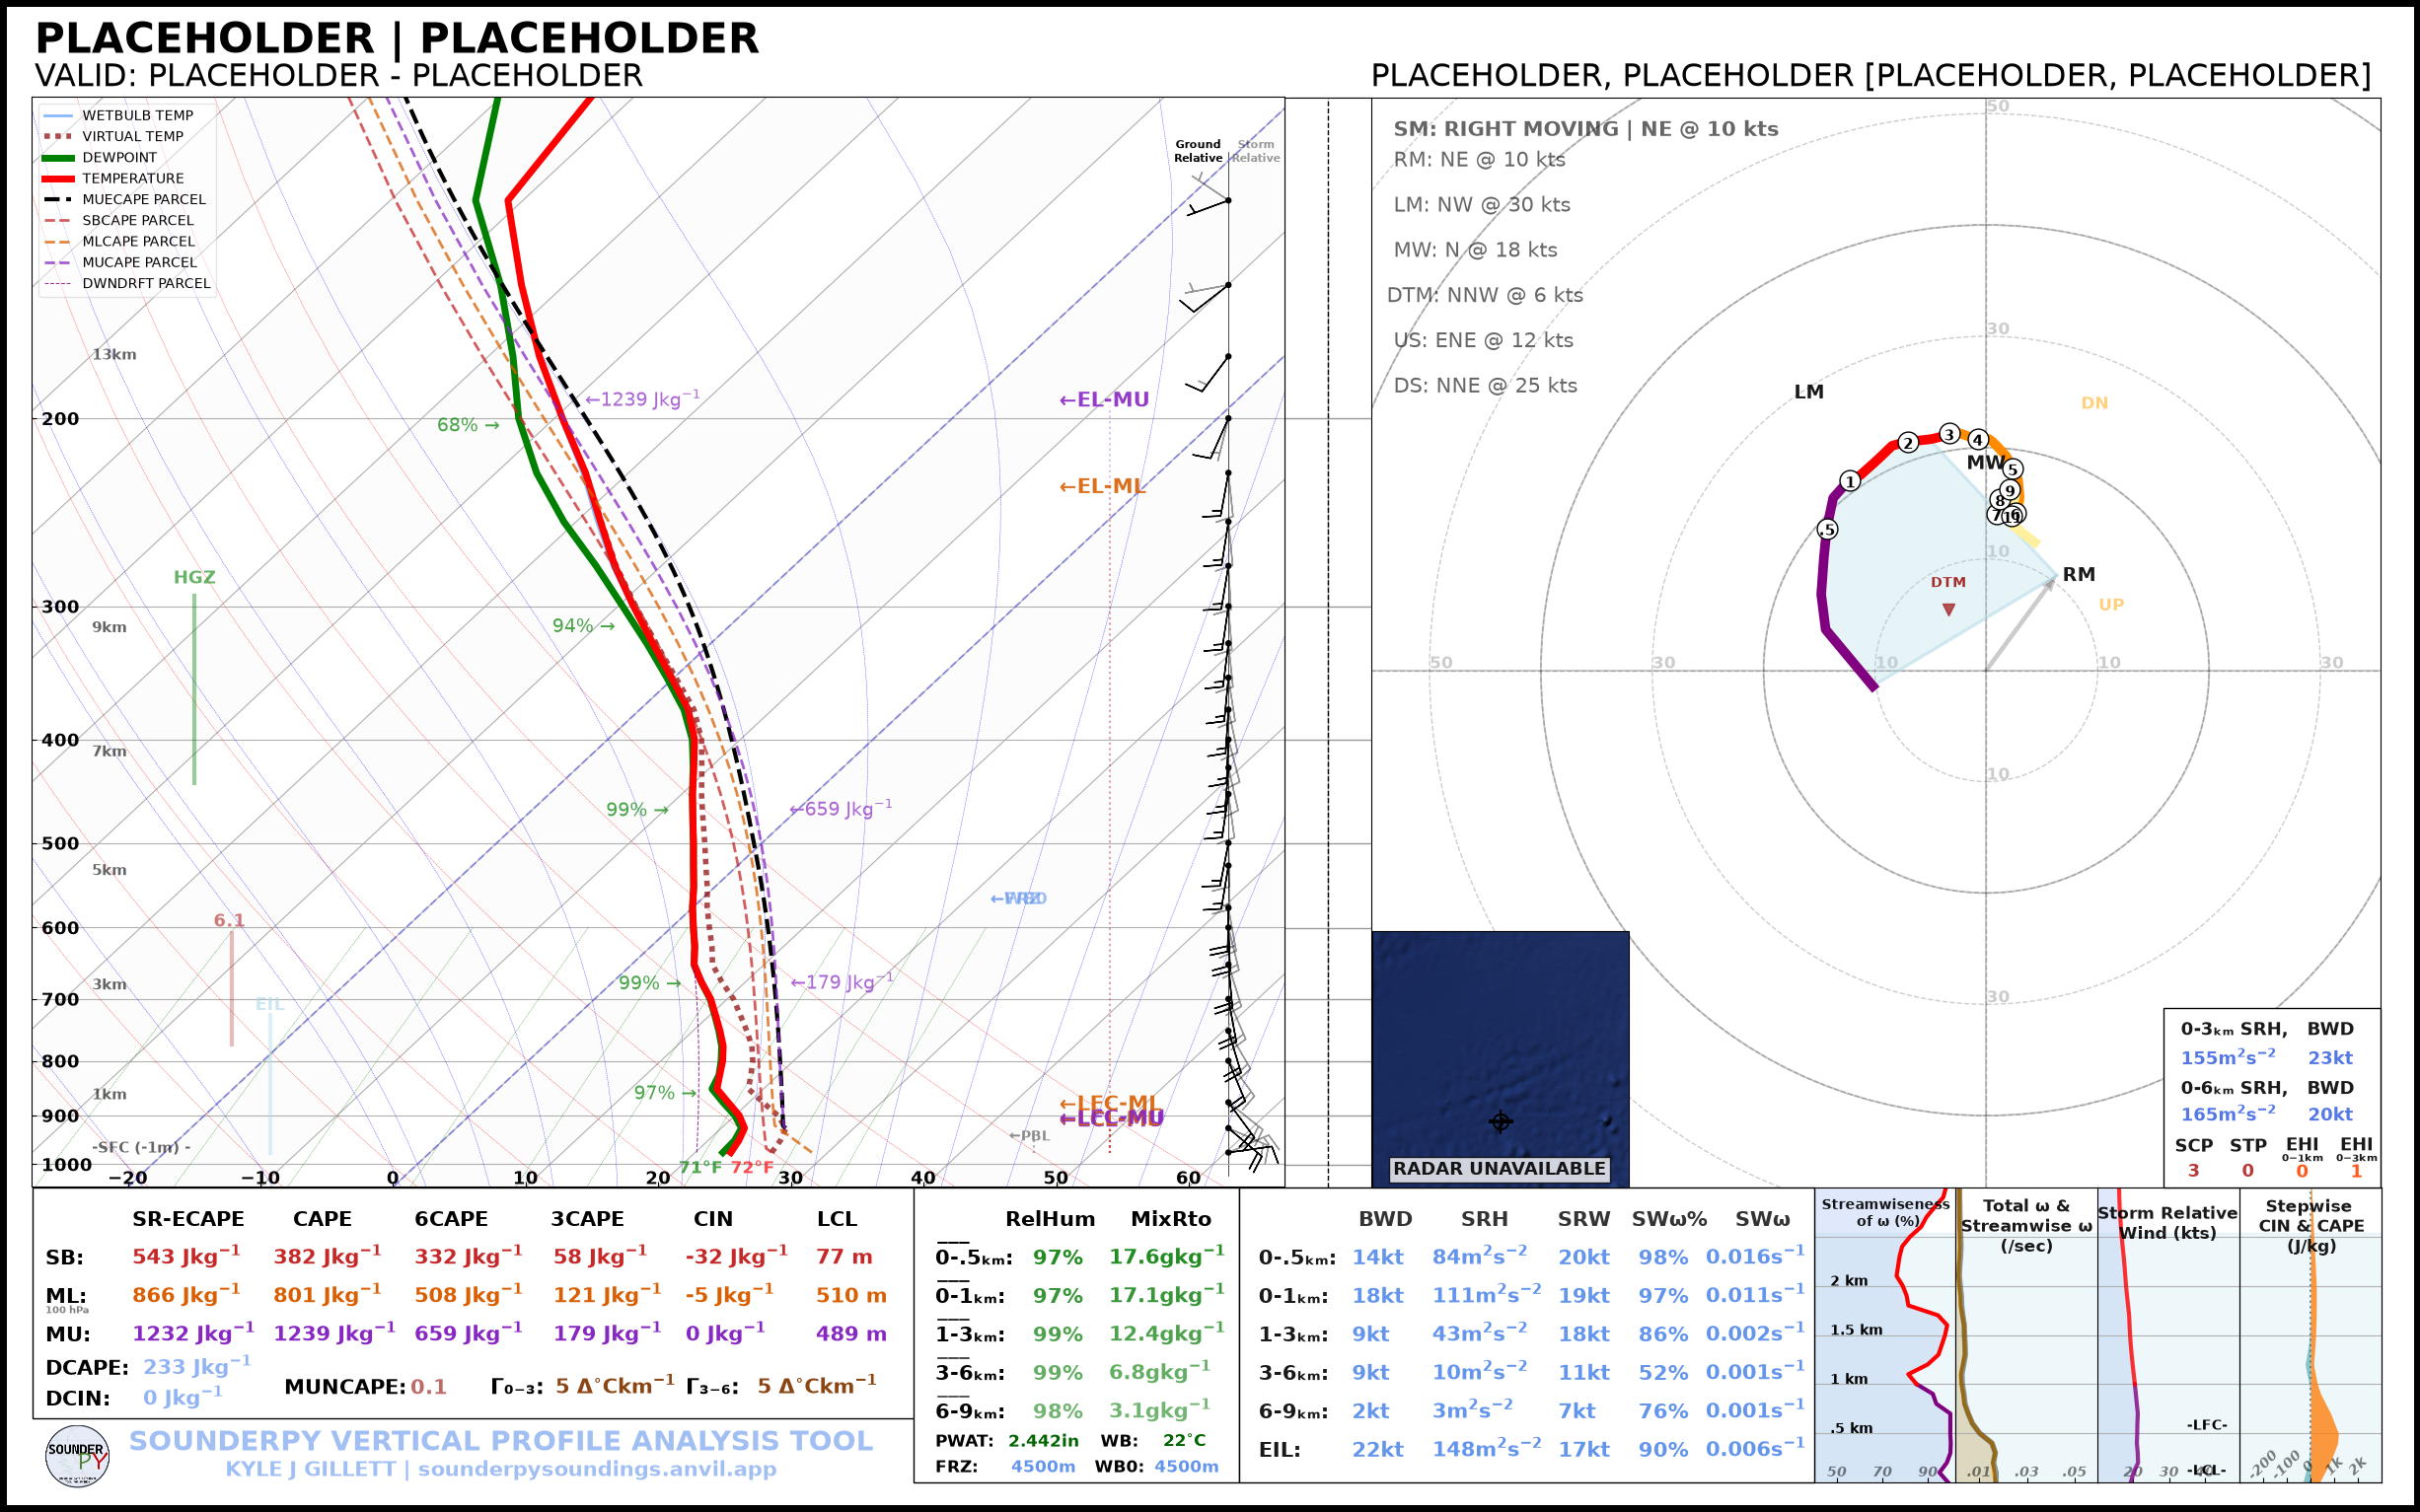

In [12]:
makeSounding('example')